In [2]:
# Same as other ipynb, but now split the wavelengths in two and later combine them
import sys
import os
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
sys.path.insert(0, os.path.abspath("../.."))
from build_spectra.linear_combination import generate_mixture_spectra

rng = np.random.default_rng(seed=None)

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

# Preferably use a GPU instead of CPU
print(f"PyTorch version: {torch.__version__}")
# --- Auto-detect GPU (CUDA or Apple MPS) — falls back to CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0
Using device: mps


In [3]:
df = pd.read_excel('../../../data/spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

# if there is a NaN, interpolate data linearly

wavelength = np.array(df['Wavelength'])

In [4]:
class Sparsemax(nn.Module):
    def forward(self, z):
        dim = 1
        z_sorted, _ = torch.sort(z, dim=dim, descending=True)
        
        css = torch.cumsum(z_sorted, dim=dim)

        z_index = torch.arange(1, z.shape[dim] + 1, device=z.device).float()
        bound = 1 + z_index * z_sorted > css
        k = bound.sum(dim=dim, keepdim=True).float()
        
        tau = (torch.gather(css, dim, (k - 1).long()) - 1) / k
        
        return torch.clamp(z - tau, min=0.0)

def training_loop(nr_epochs, epochs_no_improvement, X_train_, y_train_, X_val_, y_val_, wavelength):  
    N_species = y_train_.shape[1] 
    print(N_species)

    print(X_train_.shape, X_val_.shape)
    
    X_train_ = X_train_.float()
    X_val_ = X_val_.float()

    model = nn.Sequential(
        nn.Linear(len(wavelength), 128),
        nn.ReLU(),
        nn.Linear(128, N_species),
        Sparsemax()
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5, min_lr=1e-6)

    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []
    epochs_list = []

    X_train_ = X_train_.reshape(-1, len(wavelength)).float()
    X_val_ = X_val_.reshape(-1, len(wavelength)).float()
    
    y_train_ = y_train_.reshape(-1, N_species).float()
    y_val_ = y_val_.reshape(-1, N_species).float()

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_)
        
        loss = criterion(pred, y_train_)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            # dim=0 averages across the 4000 samples, leaving 9 species MAEs
            train_mae_per_species = torch.mean(torch.abs(pred - y_train_), dim=0).tolist()

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_)
            loss_val = criterion(pred_val, y_val_)

            val_mae_per_species = torch.mean(torch.abs(pred_val - y_val_), dim=0).tolist()

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        
        train_maes.append(train_mae_per_species)
        val_maes.append(val_mae_per_species)

        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement > epochs_no_improvement:
            print(f"Early stopping triggered at epoch {epoch}")
            break
            
        scheduler.step(loss_val.item())
        
    return train_losses, val_losses, train_maes, val_maes, epochs_list, model

In [5]:
mixtures_df, weights_df = generate_mixture_spectra(df, combination_sizes=(3, 4, 5, 6, 7, 8, 9), n_mixtures_per_combination=5)

mixture_columns = weights_df['mixture_name'].tolist()
X_numpy = mixtures_df[mixture_columns].T.values 

y_df = weights_df.drop(columns=['mixture_name'])
y_numpy = y_df.values

X_train, X_val, y_train, y_val = train_test_split(X_numpy, y_numpy, test_size=0.2, random_state=42)

X_train_ = torch.tensor(X_train, dtype=torch.float32)
X_val_ = torch.tensor(X_val, dtype=torch.float32)
y_train_ = torch.tensor(y_train, dtype=torch.float32)
y_val_ = torch.tensor(y_val, dtype=torch.float32)

noise_level = 0.1

train_noise = noise_level * torch.randn_like(X_train_)
X_train_ += train_noise

val_noise = noise_level * torch.randn_like(X_val_)
X_val_ += val_noise


In [6]:
# split data into two spectra
_, n_wavelength = X_train_.shape
cut_off = .5
X_train_low,  X_train_high  = X_train_[:, :int(cut_off*n_wavelength)], X_train_[:, int(cut_off*n_wavelength):]
X_val_low,    X_val_high    = X_val_[:,   :int(cut_off*n_wavelength)], X_val_[:,   int(cut_off*n_wavelength):]

# Normalize X
mean_low = X_train_low.mean(dim=0, keepdim=True)
std_low = X_train_low.std(dim=0, keepdim=True) + 1e-8
X_train_low = (X_train_low - mean_low) / std_low
X_val_low = (X_val_low - mean_low) / std_low

mean_high = X_train_high.mean(dim=0, keepdim=True)
std_high = X_train_high.std(dim=0, keepdim=True) + 1e-8
X_train_high = (X_train_high - mean_high) / std_high
X_val_high = (X_val_high - mean_high) / std_high

wavelength_low,  wavelength_high  = wavelength[:int(cut_off*n_wavelength)], wavelength[int(cut_off*n_wavelength):]

In [7]:
train_losses_low, val_losses_low, train_maes_low, val_maes_low, epochs_list_low, trained_model_low = training_loop(10000, 8, X_train_low, y_train_, X_val_low, y_val_, wavelength_low)

9
torch.Size([1864, 225]) torch.Size([466, 225])
Early stopping triggered at epoch 260


In [8]:
train_losses_high, val_losses_high, train_maes_high, val_maes_high, epochs_list_high, trained_model_high = training_loop(10000, 8, X_train_high, y_train_, X_val_high, y_val_, wavelength_high)

9
torch.Size([1864, 226]) torch.Size([466, 226])
Early stopping triggered at epoch 647


In [9]:
y_val = torch.tensor(y_val_, dtype=torch.float32)

trained_model_low.eval()
trained_model_high.eval()

with torch.no_grad():
    pred_val_low = trained_model_low(X_val_low)
    pred_val_high = trained_model_high(X_val_high)
    pred_val = (pred_val_high + pred_val_low) / 2
    
    # Calculate absolute error for every prediction
    abs_errors = torch.abs(pred_val - y_val)

# Calculate 
per_mixture_mae = torch.mean(abs_errors, dim=1).cpu().numpy()
per_mixture_std = torch.std(abs_errors, dim=1).cpu().numpy()
overall_mean_mae = np.mean(per_mixture_mae)

per_species_mae = torch.mean(abs_errors, dim=0).cpu().numpy()
per_species_std = torch.std(abs_errors, dim=0).cpu().numpy()

species_names = [
    "Diatom_Ptricornutum", "Diatom_Csimplex", 
    "Chlamydomonas_Cprisculi", "Chlamydomonas_Creindhardtii", 
    "Dinoflagellate_Symbiodiniumsp", "Dinoflagellate_Smicroadriaticum",
    "Dinoflagellate_Dtrenchii", "Dinoflagellate_Cgoreaui",
    "Cyanobacteria_Synechosystis"
]

/var/folders/_7/zxtqxl4x011ccx8hf3cwf7dw0000gn/T/ipykernel_3199/570490684.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_val = torch.tensor(y_val_, dtype=torch.float32)


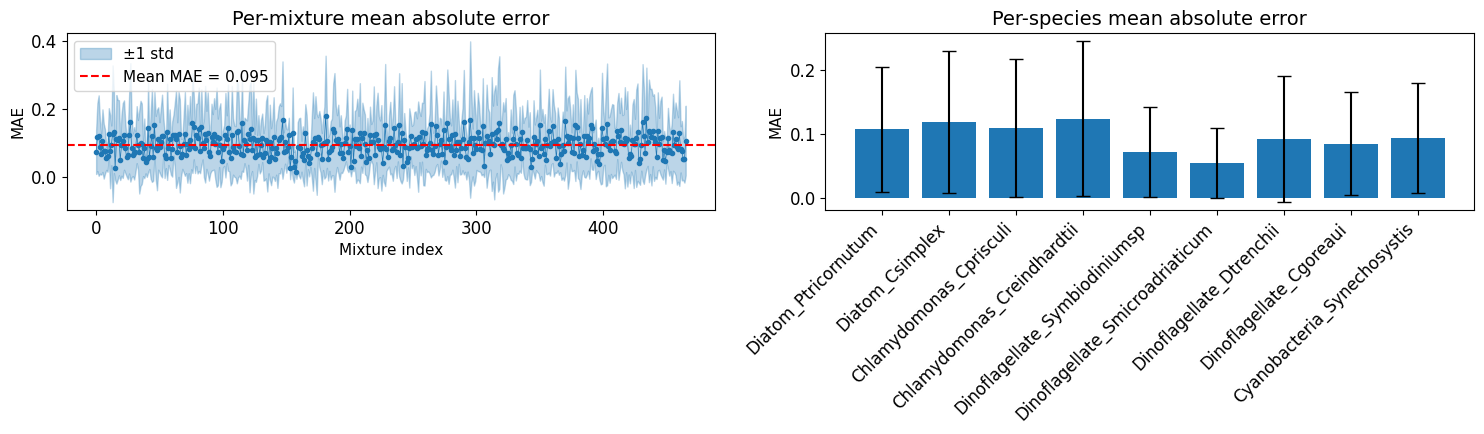

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax1 = axes[0]
mixture_indices = np.arange(len(per_mixture_mae))

ax1.plot(mixture_indices, per_mixture_mae, marker='.', linestyle='-', lw=0.5, markersize=6, color='tab:blue')

ax1.fill_between(mixture_indices, 
                 per_mixture_mae - per_mixture_std, 
                 per_mixture_mae + per_mixture_std, 
                 alpha=0.3, color='tab:blue', label='±1 std')

ax1.axhline(overall_mean_mae, color='red', linestyle='--', lw=1.5, label=f'Mean MAE = {overall_mean_mae:.3f}')

ax1.set_title("Per-mixture mean absolute error", fontsize=14)
ax1.set_xlabel("Mixture index", fontsize=11)
ax1.set_ylabel("MAE", fontsize=11)
ax1.legend(loc='upper left', fontsize=11)

ax2 = axes[1]
x_pos = np.arange(len(species_names))

ax2.bar(x_pos, per_species_mae, yerr=per_species_std, capsize=5, color='tab:blue')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(species_names, rotation=45, ha="right")

ax2.set_title("Per-species mean absolute error", fontsize=14)
ax2.set_ylabel("MAE", fontsize=11)

plt.tight_layout()
plt.show()

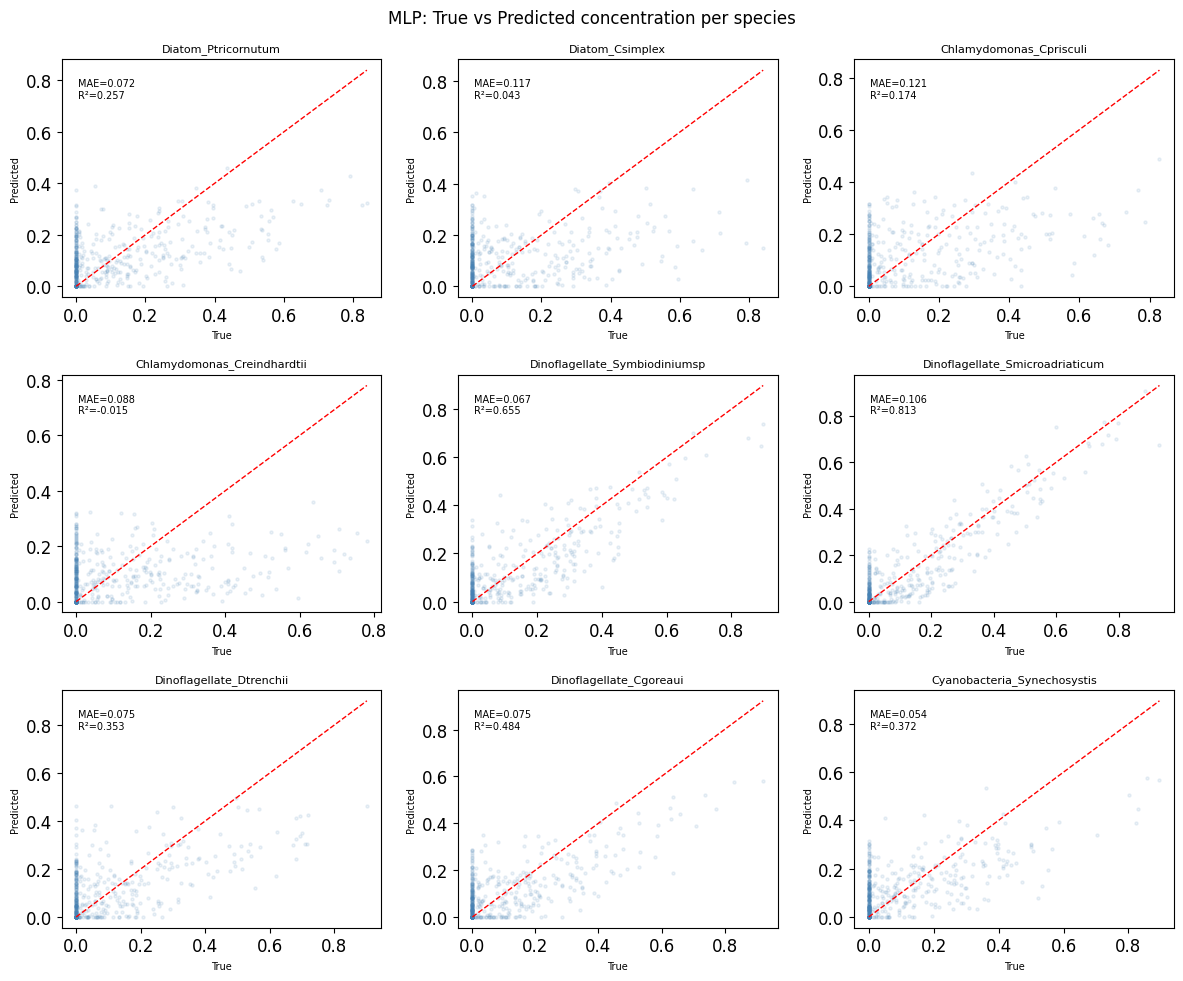

In [11]:
n_species = len(species_names)
ground_truth = y_val_
estimated_concentrations = pred_val.cpu().numpy()  # fix type

# --- Per-species metrics ---
r2_per_species  = [r2_score(ground_truth[:, i], estimated_concentrations[:, i]) for i in range(n_species)]

# --- Scatter plots: true vs predicted per species ---
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(species_names, axes)):
    ax.scatter(ground_truth[:, i], estimated_concentrations[:, i], alpha=0.1, s=5, color="steelblue")
    # Perfect prediction line
    lim = [0, max(ground_truth[:, i].max(), estimated_concentrations[:, i].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("True", fontsize=7)
    ax.set_ylabel("Predicted", fontsize=7)
    ax.text(0.05, 0.92, f"MAE={per_mixture_mae[i]:.3f}\nR²={r2_per_species[i]:.3f}",
            transform=ax.transAxes, fontsize=7, verticalalignment='top')

plt.suptitle("MLP: True vs Predicted concentration per species", fontsize=12)
plt.tight_layout()
plt.show()
# shows predicted concentration values on y-axis versus the true concentration on x-axis. If it is perfect, it should follow the red line (linear). 
# R^2 determines how well the linear fit is. For noise_level = 0, it is perfect!